In [2]:
import numpy as np
import mne
import os
import pywt
import scipy.io as sio
from scipy import signal
from scipy.signal import hilbert
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from scipy.ndimage import gaussian_filter1d


from NeuralFieldManifold.models import AR, TAR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

# capture future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()

In [3]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import plotly.graph_objects as go
from NeuralFieldManifold.fits.two_torus import two_torus_fit, plot_two_torus_fit

/home/potato/miniconda3/envs/manifold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Moneky

In [23]:
def sweep_fits(windows, lam=0.1, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(two_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

## monkey 15 mins

In [34]:
xs, time, Fs = np.load("data/monkey_15_min.npz").values()
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

In [35]:
window_size = 5
optimal_tau = 30
max_start = (len(xs_rescaled) / Fs) - window_size
sampled_starts = np.sort(np.random.uniform(0, max_start, 1000))

time_sweep_windows = make_windows(
    xs_rescaled,
    Fs=Fs,
    embedding_dim=3,
    tau=optimal_tau,
    starts_sec=sampled_starts.tolist(),
    window_sec=window_size,
)
torus_sweep = sweep_fits(time_sweep_windows)


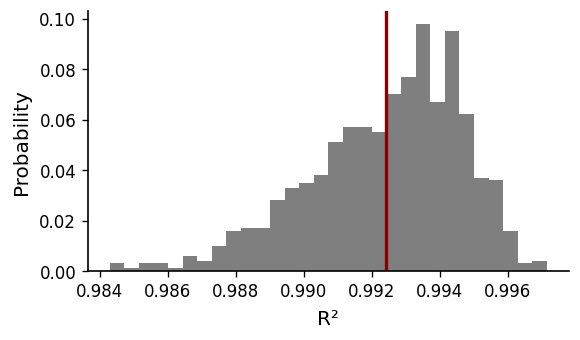

In [42]:
r_squared_vals = np.array([f['r_squared'] for f in torus_sweep])
r_squared_weights = np.ones_like(r_squared_vals) / len(r_squared_vals)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(r_squared_vals, bins=30, weights=r_squared_weights, color='black', alpha=0.5)
ax.axvline(r_squared_vals.mean(), color=color_alt, linewidth=2)
prettify(ax, xlabel="R²", ylabel="Probability", add_legend=False)
plt.tight_layout()
plt.show()


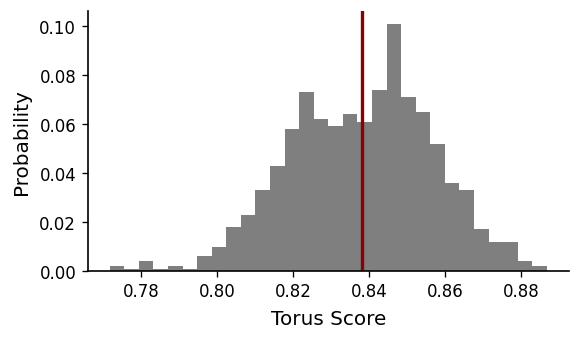

In [43]:
torus_score_vals = np.array([f['frac_inside'] for f in torus_sweep])
torus_score_weights = np.ones_like(torus_score_vals) / len(torus_score_vals)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(torus_score_vals, bins=30, weights=torus_score_weights, color='black', alpha=0.5)
ax.axvline(torus_score_vals.mean(), color=color_alt, linewidth=2)
prettify(ax, xlabel="Torus Score", ylabel="Probability", add_legend=False)
plt.tight_layout()
plt.show()


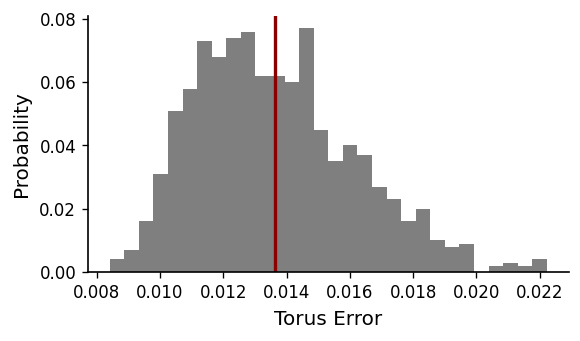

In [44]:
mean_error_vals = np.array([f['mean_error'] for f in torus_sweep])
mean_error_weights = np.ones_like(mean_error_vals) / len(mean_error_vals)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(mean_error_vals, bins=30, weights=mean_error_weights, color='black', alpha=0.5)
ax.axvline(mean_error_vals.mean(), color=color_alt, linewidth=2)
prettify(ax, xlabel="Torus Error", ylabel="Probability", add_legend=False)
plt.tight_layout()
plt.show()


## others


In [5]:
xs, Fs, tau = np.load("data/monkey_lfp.npz").values()

# xs is -something to +something. we need it to -1 to +1 for comparablility
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1
xs.shape, Fs, tau

((10000,), array(500), array(30))

In [ ]:
window_size = 5
time_starts = np.arange(0, (len(xs_rescaled) / Fs) - window_size, 0.1)
time_sweep_windows = []
for start_time in tqdm(time_starts, desc="Time sweep"):
    time_sweep_windows.append(
        make_windows(
            xs_rescaled,
            Fs=Fs,
            embedding_dim=3,
            tau=30,
            starts_sec=[float(start_time)],
            window_sec=window_size,
        )[0]
    )
torus_sweep = sweep_fits(time_sweep_windows)


tau_start_sec = 10
tau_window_sec = 2
taus = np.arange(1, 100, 1)

tau_windows = []
for tau_val in tqdm(taus, desc="Tau sweep"):
    tau_windows.append(
        {
            **make_windows(
                xs_rescaled,
                Fs=Fs,
                embedding_dim=3,
                tau=int(tau_val),
                starts_sec=[tau_start_sec],
                window_sec=tau_window_sec,
            )[0],
            'tau': int(tau_val),
        }
    )
tau_sweep = sweep_fits(tau_windows)

window_start_sec = 0
tau_fixed = 30
max_window_sec = np.floor((len(xs_rescaled) / Fs) * 10) / 10
window_sizes = np.round(np.arange(0.1, max_window_sec + 0.05, 0.1), 1)
min_window_sec = ((3 - 1) * tau_fixed + 1) / Fs
window_sizes = window_sizes[window_sizes >= min_window_sec]

window_sweep_windows = []
for window_sec in tqdm(window_sizes, desc="Window sweep"):
    window_sweep_windows.append(
        {
            **make_windows(
                xs_rescaled,
                Fs=Fs,
                embedding_dim=3,
                tau=tau_fixed,
                starts_sec=[window_start_sec],
                window_sec=float(window_sec),
            )[0],
            'window_sec': float(window_sec),
        }
    )
window_sweep = sweep_fits(window_sweep_windows)


Window sweep: 100%|██████████| 199/199 [00:02<00:00, 67.84it/s]


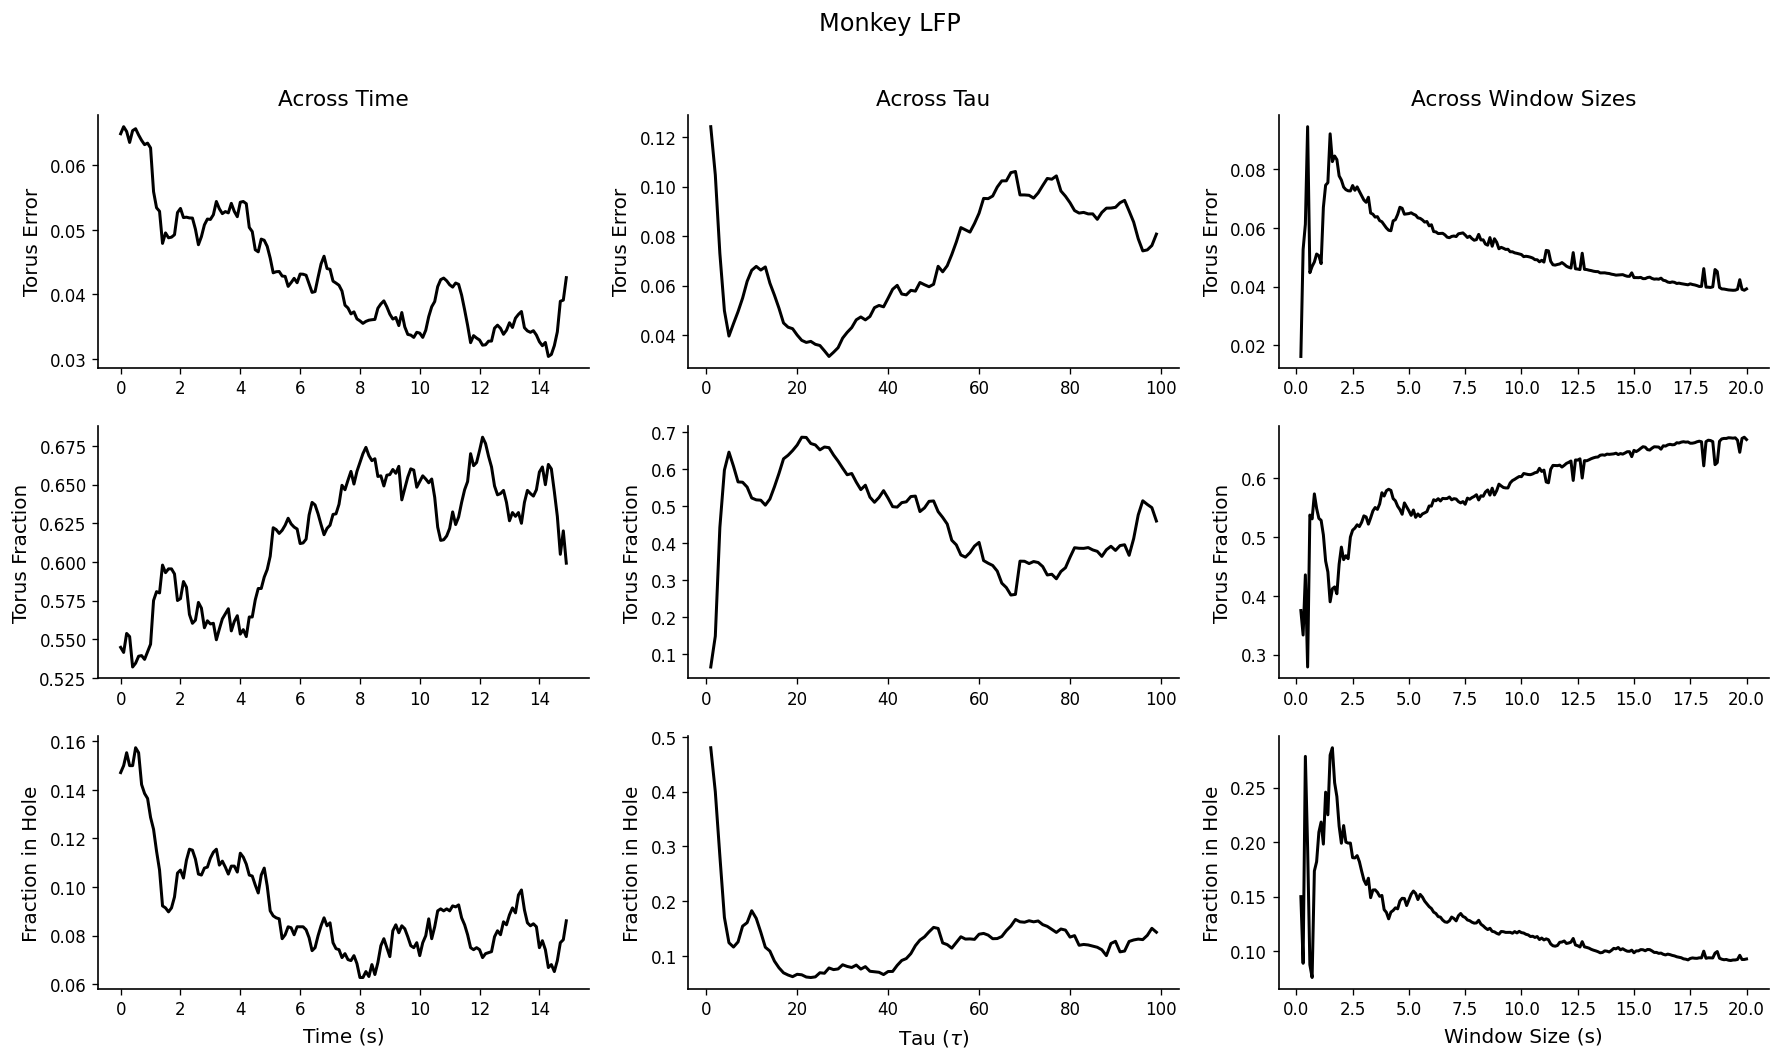

In [6]:
time_errors = np.array([fit['mean_error'] for fit in torus_sweep])
time_fraction = np.array([fit['frac_inside'] for fit in torus_sweep])
time_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in torus_sweep])
tau_errors = np.array([fit['mean_error'] for fit in tau_sweep])
tau_fraction = np.array([fit['frac_inside'] for fit in tau_sweep])
tau_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in tau_sweep])
window_errors = np.array([fit['mean_error'] for fit in window_sweep])
window_fraction = np.array([fit['frac_inside'] for fit in window_sweep])
window_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in window_sweep])

metric_rows = [
    ("Torus Error", [time_errors, tau_errors, window_errors]),
    ("Torus Fraction", [time_fraction, tau_fraction, window_fraction]),
    ("Fraction in Hole", [time_fraction_in_hole, tau_fraction_in_hole, window_fraction_in_hole]),
]

sweep_columns = [
    ("Across Time", time_starts, "Time (s)"),
    ("Across Tau", taus, "Tau ($\\tau$)"),
    ("Across Window Sizes", window_sizes, "Window Size (s)"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for col, (col_title, x_values, bottom_xlabel) in enumerate(sweep_columns):
    for row, (y_label, y_series_by_col) in enumerate(metric_rows):
        ax = axes[row, col]
        ax.plot(x_values, y_series_by_col[col], "k-")
        if row == 0:
            ax.set_title(col_title)
        prettify(
            ax,
            xlabel=bottom_xlabel if row == 2 else "",
            ylabel=y_label,
            add_legend=False,
        )

fig.suptitle("Monkey LFP")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [9]:
plot_two_torus_fit(torus_sweep[100])

In [55]:
# Time x Tau sweep with fixed 5-second windows
# Reload monkey data to avoid stale variables
xs, Fs, tau = np.load("data/monkey_lfp.npz").values()
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

window_size = 5.0
time_step = 0.05
embedding_dim = 3

Fs_scalar = float(np.asarray(Fs).squeeze())
duration_sec = len(xs_rescaled) / Fs_scalar
max_start = max(duration_sec - window_size, 0.0)
time_starts_grid = np.arange(0.0, max_start + 1e-9, time_step)

max_tau_for_window = int((window_size * Fs_scalar - 1) // (embedding_dim - 1))
tau_values_grid = np.arange(1, min(100, max_tau_for_window + 1), 1)

all_windows = []
for j, tau_val in enumerate(tqdm(tau_values_grid, desc="Building windows")):
    tau_windows = make_windows(
        xs_rescaled,
        Fs=Fs_scalar,
        embedding_dim=embedding_dim,
        tau=int(tau_val),
        starts_sec=time_starts_grid,
        window_sec=window_size,
    )
    for i, w in enumerate(tau_windows):
        w["time_idx"] = i
        w["tau_idx"] = j
        all_windows.append(w)

all_fits = sweep_fits(all_windows)

err_mat = np.full((len(time_starts_grid), len(tau_values_grid)), np.nan)
frac_mat = np.full_like(err_mat, np.nan)
hole_frac_mat = np.full_like(err_mat, np.nan)

for fit in all_fits:
    i = fit["time_idx"]
    j = fit["tau_idx"]
    err_mat[i, j] = fit["mean_error"]
    frac_mat[i, j] = fit["frac_inside"]
    hole_frac_mat[i, j] = fit["frac_in_hole"]

Building windows: 100%|██████████| 99/99 [00:00<00:00, 272.34it/s]


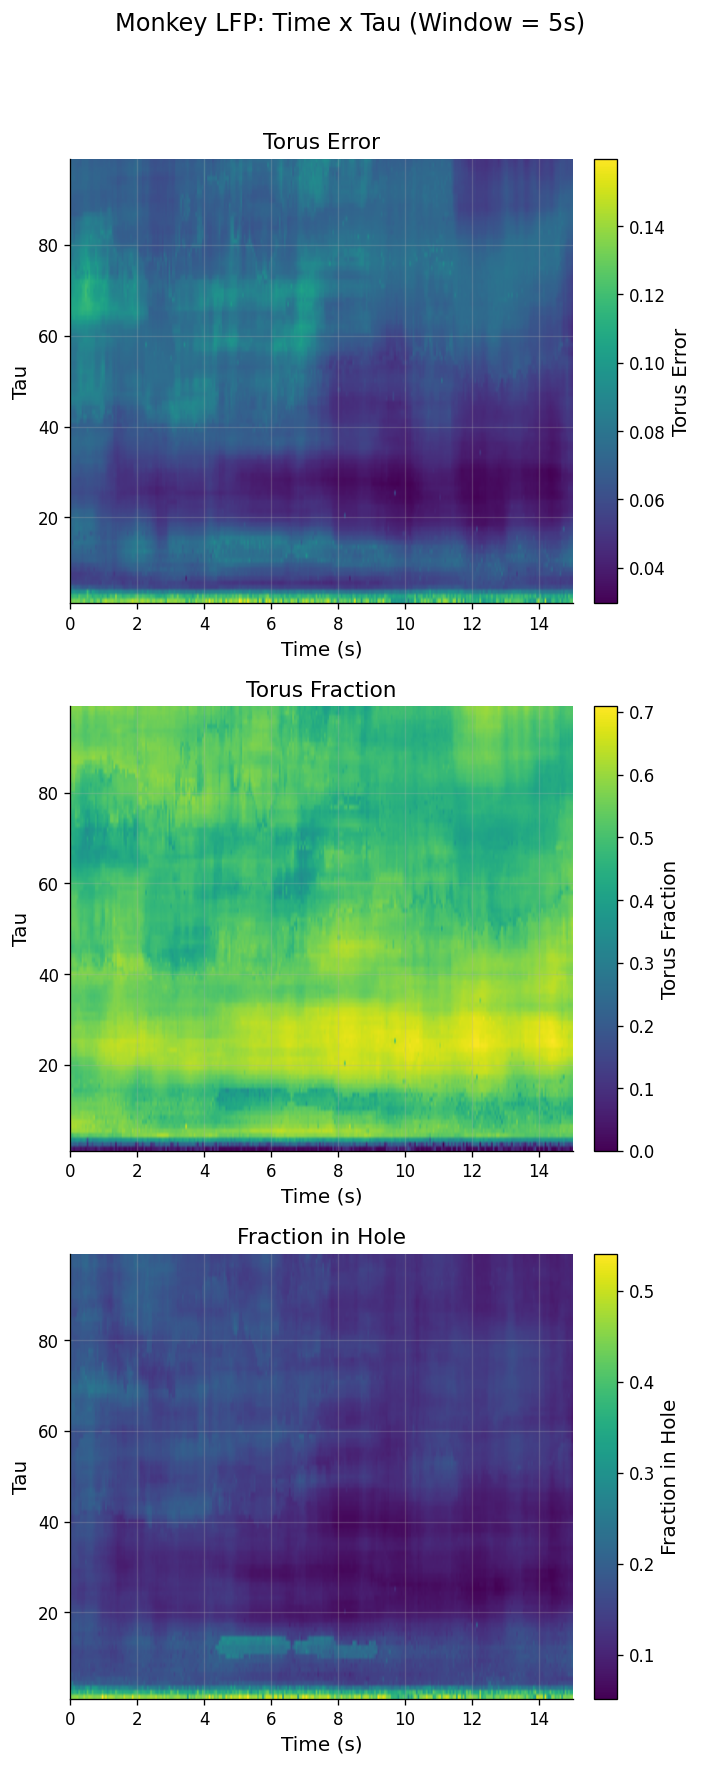

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(6, 15))

heatmaps = [
    ("Torus Error", err_mat, "Torus Error"),
    ("Torus Fraction", frac_mat, "Torus Fraction"),
    ("Fraction in Hole", hole_frac_mat, "Fraction in Hole"),
]

for idx, (ax, (title, mat, cbar_label)) in enumerate(zip(axes, heatmaps)):
    im = ax.imshow(
        mat.T,
        origin="lower",
        aspect="auto",
        extent=[time_starts_grid[0], time_starts_grid[-1], tau_values_grid[0], tau_values_grid[-1]],
        cmap="viridis",
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tau")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

fig.suptitle("Monkey LFP: Time x Tau (Window = 5s)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Mice

In [12]:
from NeuralFieldManifold.fits import one_torus_fit, plot_one_torus_fit

In [13]:
def sweep_fits(windows, lam=1.0, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(one_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

In [14]:
xs, Fs, tau = np.load("data/mice_lfp.npz").values()
xs.shape, Fs, tau

((2500,), array(500.), array(10))

In [15]:
# xs is -something to +something. we need it to -1 to +1 for comparablility
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

window_size = 1
time_starts = np.arange(0, (len(xs_rescaled) / Fs) - window_size, 0.05)
time_sweep_windows = []
for start_time in tqdm(time_starts, desc="Time sweep"):
    time_sweep_windows.append(
        make_windows(
            xs_rescaled,
            Fs=Fs,
            embedding_dim=3,
            tau=10,
            starts_sec=[float(start_time)],
            window_sec=window_size,
        )[0]
    )
torus_sweep = sweep_fits(time_sweep_windows)


tau_start_sec = 1
tau_window_sec = 2
taus = np.arange(1, 100, 1)

tau_windows = []
for tau_val in tqdm(taus, desc="Tau sweep"):
    tau_windows.append(
        {
            **make_windows(
                xs_rescaled,
                Fs=Fs,
                embedding_dim=3,
                tau=int(tau_val),
                starts_sec=[tau_start_sec],
                window_sec=tau_window_sec,
            )[0],
            'tau': int(tau_val),
        }
    )
tau_sweep = sweep_fits(tau_windows)

window_start_sec = 0
tau_fixed = 10
max_window_sec = np.floor((len(xs_rescaled) / Fs) * 10) / 10
window_sizes = np.round(np.arange(0.1, max_window_sec + 0.05, 0.1), 1)
min_window_sec = ((3 - 1) * tau_fixed + 1) / Fs
window_sizes = window_sizes[window_sizes >= min_window_sec]

window_sweep_windows = []
for window_sec in tqdm(window_sizes, desc="Window sweep"):
    window_sweep_windows.append(
        {
            **make_windows(
                xs_rescaled,
                Fs=Fs,
                embedding_dim=3,
                tau=tau_fixed,
                starts_sec=[window_start_sec],
                window_sec=float(window_sec),
            )[0],
            'window_sec': float(window_sec),
        }
    )
window_sweep = sweep_fits(window_sweep_windows)


Window sweep: 100%|██████████| 50/50 [00:00<00:00, 67.75it/s]


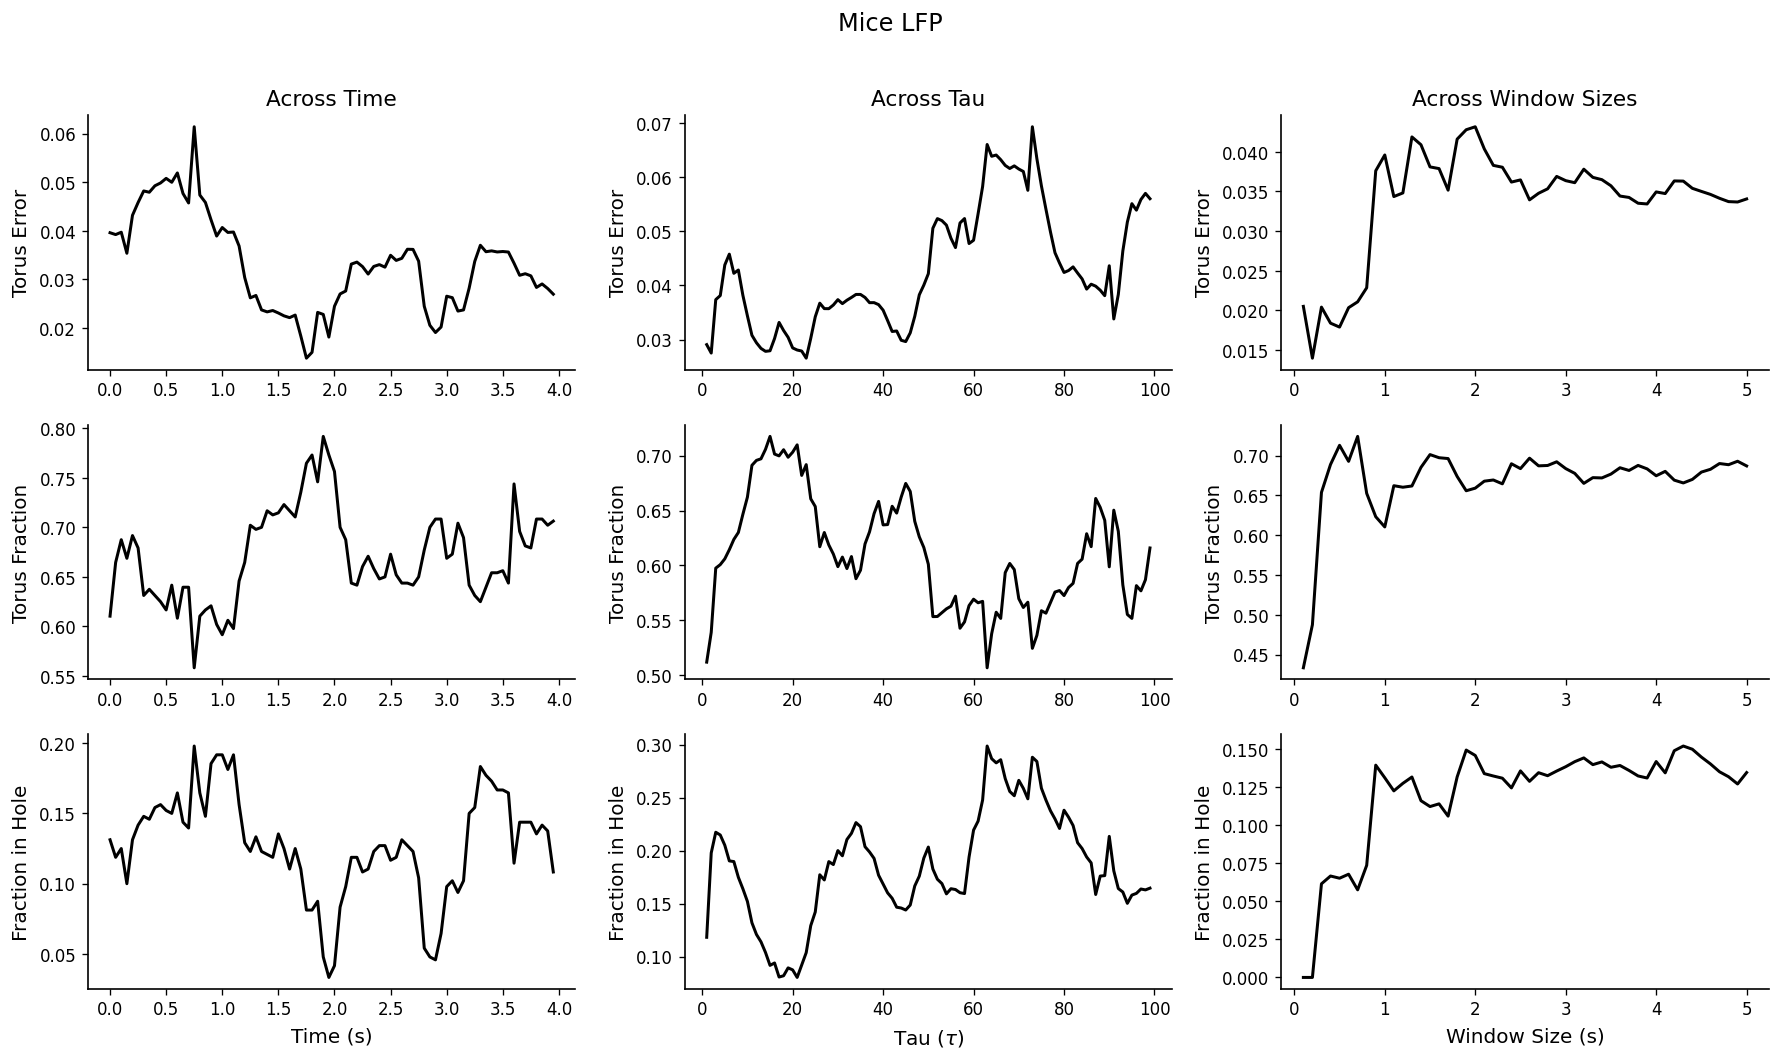

In [16]:
time_errors = np.array([fit['mean_error'] for fit in torus_sweep])
time_fraction = np.array([fit['frac_inside'] for fit in torus_sweep])
time_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in torus_sweep])
tau_errors = np.array([fit['mean_error'] for fit in tau_sweep])
tau_fraction = np.array([fit['frac_inside'] for fit in tau_sweep])
tau_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in tau_sweep])
window_errors = np.array([fit['mean_error'] for fit in window_sweep])
window_fraction = np.array([fit['frac_inside'] for fit in window_sweep])
window_fraction_in_hole = np.array([fit['frac_in_hole'] for fit in window_sweep])

metric_rows = [
    ("Torus Error", [time_errors, tau_errors, window_errors]),
    ("Torus Fraction", [time_fraction, tau_fraction, window_fraction]),
    ("Fraction in Hole", [time_fraction_in_hole, tau_fraction_in_hole, window_fraction_in_hole]),
]

sweep_columns = [
    ("Across Time", time_starts, "Time (s)"),
    ("Across Tau", taus, "Tau ($\\tau$)"),
    ("Across Window Sizes", window_sizes, "Window Size (s)"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for col, (col_title, x_values, bottom_xlabel) in enumerate(sweep_columns):
    for row, (y_label, y_series_by_col) in enumerate(metric_rows):
        ax = axes[row, col]
        ax.plot(x_values, y_series_by_col[col], "k-")
        if row == 0:
            ax.set_title(col_title)
        prettify(
            ax,
            xlabel=bottom_xlabel if row == 2 else "",
            ylabel=y_label,
            add_legend=False,
        )

fig.suptitle("Mice LFP")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [21]:
plot_one_torus_fit(torus_sweep[50])

In [22]:
# Time x Tau sweep with fixed 1-second windows
# Reload mice data to avoid stale monkey variables
xs, Fs, tau = np.load("data/mice_lfp.npz").values()
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

window_size = 1.0
time_step = 0.05
embedding_dim = 3

Fs_scalar = float(np.asarray(Fs).squeeze())
duration_sec = len(xs_rescaled) / Fs_scalar
max_start = max(duration_sec - window_size, 0.0)
time_starts_grid = np.arange(0.0, max_start + 1e-9, time_step)

max_tau_for_window = int((window_size * Fs_scalar - 1) // (embedding_dim - 1))
if max_tau_for_window < 1:
    raise ValueError("Window size is too short for the selected embedding dimension.")
tau_values_grid = np.arange(1, min(100, max_tau_for_window + 1), 1)

all_windows = []
for j, tau_val in enumerate(tqdm(tau_values_grid, desc="Building windows")):
    tau_windows = make_windows(
        xs_rescaled,
        Fs=Fs_scalar,
        embedding_dim=embedding_dim,
        tau=int(tau_val),
        starts_sec=time_starts_grid,
        window_sec=window_size,
    )
    for i, w in enumerate(tau_windows):
        w["time_idx"] = i
        w["tau_idx"] = j
        all_windows.append(w)

all_fits = sweep_fits(all_windows)

err_mat = np.full((len(time_starts_grid), len(tau_values_grid)), np.nan)
frac_mat = np.full_like(err_mat, np.nan)
hole_frac_mat = np.full_like(err_mat, np.nan)

for fit in all_fits:
    i = fit["time_idx"]
    j = fit["tau_idx"]
    err_mat[i, j] = fit["mean_error"]
    frac_mat[i, j] = fit["frac_inside"]
    hole_frac_mat[i, j] = fit["frac_in_hole"]

Building windows: 100%|██████████| 99/99 [00:01<00:00, 61.91it/s]


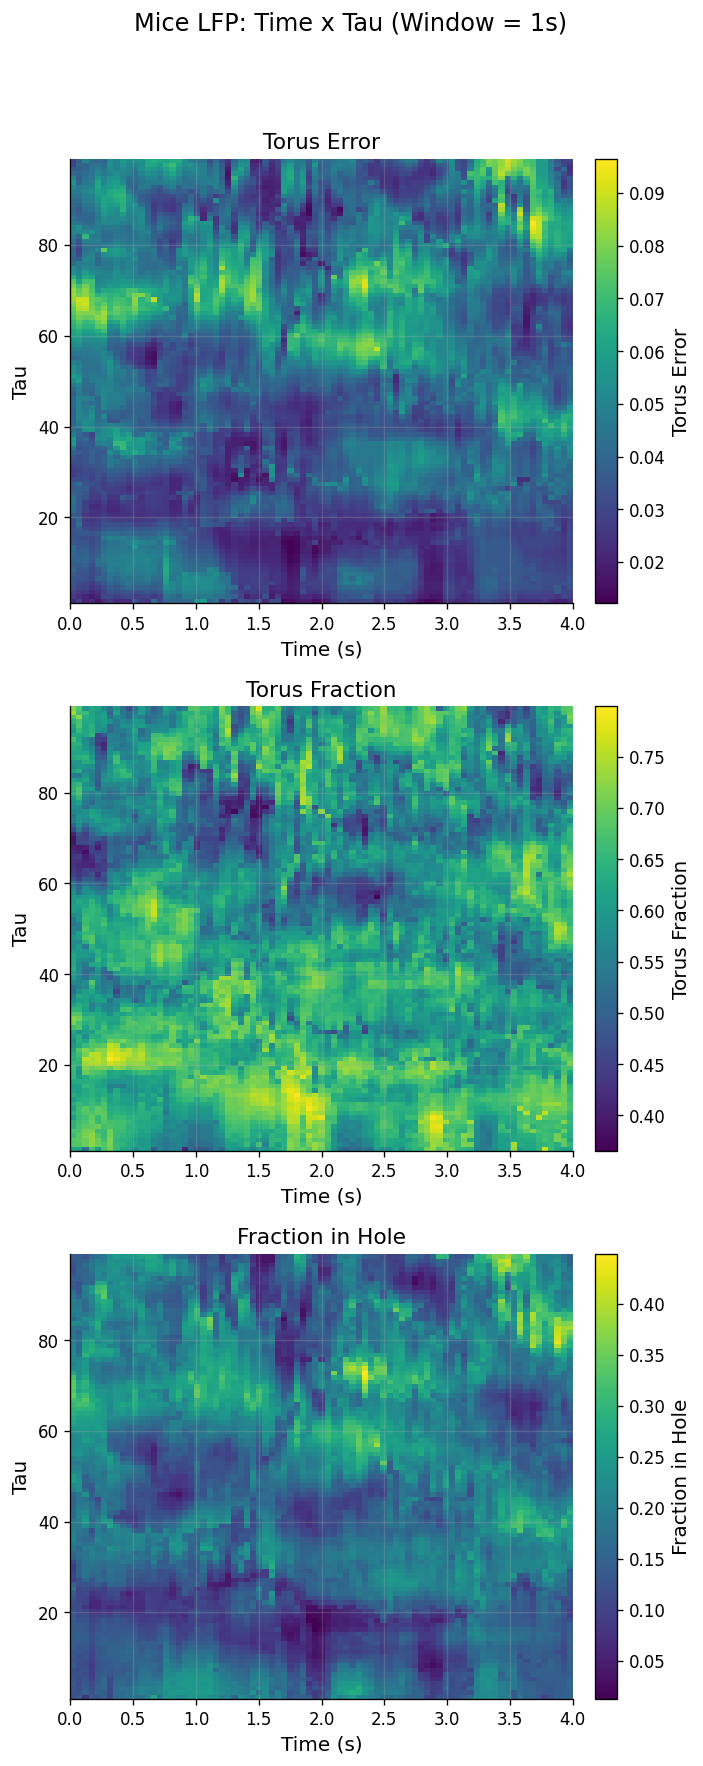

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(6, 15))

heatmaps = [
    ("Torus Error", err_mat, "Torus Error"),
    ("Torus Fraction", frac_mat, "Torus Fraction"),
    ("Fraction in Hole", hole_frac_mat, "Fraction in Hole"),
]

for idx, (ax, (title, mat, cbar_label)) in enumerate(zip(axes, heatmaps)):
    im = ax.imshow(
        mat.T,
        origin="lower",
        aspect="auto",
        extent=[time_starts_grid[0], time_starts_grid[-1], tau_values_grid[0], tau_values_grid[-1]],
        cmap="viridis",
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tau")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

fig.suptitle("Mice LFP: Time x Tau (Window = 1s)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [51]:
plot_two_torus_fit(all_fits[500])